In [70]:
# 0. Setup and Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Preprocessing & Feature Selection
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB  # Added for your next step!

# Evaluation Metrics
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, silhouette_score, 
                             mean_squared_error, r2_score)
#for interface
!pip install gradio

# Ignore warnings
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [71]:
# 1. Load the dataset

# Read data
df = pd.read_csv('Healthcare.csv')

# Check for missing values 
print("Missing Values in each column:")
print(df.isnull().sum())

# Display the first 5 rows to inspect the data structure
print("\nFirst 5 rows of the dataset:")
display(df.head())

Missing Values in each column:
Patient_ID       0
Age              0
Gender           0
Symptoms         0
Symptom_Count    0
Disease          0
dtype: int64

First 5 rows of the dataset:


,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease
0,1,29,Male,"fever, back pain, shortness of breath",3,Allergy
1,2,76,Female,"insomnia, back pain, weight loss",3,Thyroid Disorder
2,3,78,Male,"sore throat, vomiting, diarrhea",3,Influenza
3,4,58,Other,"blurred vision, depression, weight loss, muscl...",4,Stroke
4,5,55,Female,"swelling, appetite loss, nausea",3,Heart Disease


In [72]:
# 2. Data Preprocessing 

# Drop Patient_ID because it has no value for analysis
df_processed = df.drop(columns=['Patient_ID'])

# Encode (Gender and Disease) to numbers
le_gender = LabelEncoder()
le_disease = LabelEncoder()

df_processed['Gender'] = le_gender.fit_transform(df_processed['Gender'])
df_processed['Disease'] = le_disease.fit_transform(df_processed['Disease'])

# split Symptoms into binary columns (0 or 1)
symptoms_dummies = df_processed['Symptoms'].str.get_dummies(sep=', ')

# Join the new binary symptom columns to our dataframe
df_processed = pd.concat([df_processed, symptoms_dummies], axis=1)

# Drop the original text 'Symptoms' column
df_processed = df_processed.drop(columns=['Symptoms'])

print("Preprocessing Complete!")
print("New Data Shape:", df_processed.shape)
display(df_processed.head())

Preprocessing Complete!
New Data Shape: (25000, 32)


,Age,Gender,Symptom_Count,Disease,abdominal pain,anxiety,appetite loss,back pain,blurred vision,chest pain,...,runny nose,shortness of breath,sneezing,sore throat,sweating,swelling,tremors,vomiting,weight gain,weight loss
0,29,1,3,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
1,76,0,3,27,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2,78,1,3,19,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
3,58,2,4,26,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
4,55,0,3,16,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [73]:
# 3.0 . Outliers Detection (Overall Summary)

print("Overall Statistical Summary:")
display(df.describe())

Overall Statistical Summary:


,Patient_ID,Age,Symptom_Count
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,45.302240,5.001440
std,7217.022701,26.106224,1.415796
min,1.000000,1.000000,3.000000
25%,6250.750000,23.000000,4.000000
50%,12500.500000,45.000000,5.000000
75%,18750.250000,68.000000,6.000000
max,25000.000000,90.000000,7.000000


Age Summary:


count    25000.000000
mean        45.302240
std         26.106224
min          1.000000
25%         23.000000
50%         45.000000
75%         68.000000
max         90.000000
Name: Age, dtype: float64

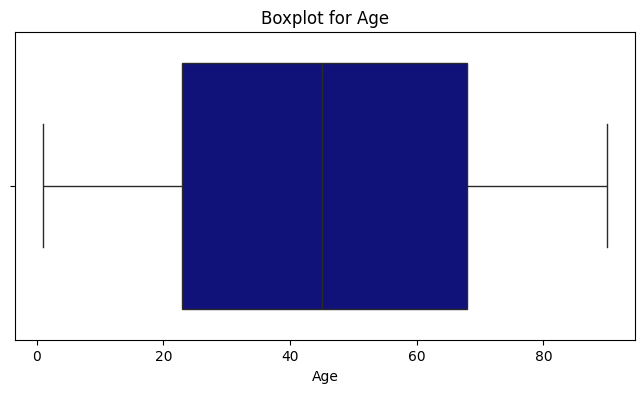

In [74]:
# 3.1 . Outliers: Age Analysis

print("Age Summary:")
display(df['Age'].describe())

plt.figure(figsize=(8, 4))
p1 = sns.boxplot(x=df_processed['Age'], color='darkblue')
plt.title('Boxplot for Age')
plt.show()

Symptom Count Summary:


count    25000.000000
mean         5.001440
std          1.415796
min          3.000000
25%          4.000000
50%          5.000000
75%          6.000000
max          7.000000
Name: Symptom_Count, dtype: float64

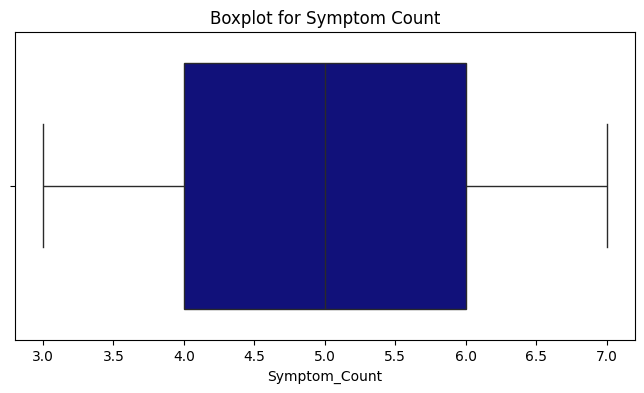

In [75]:
# 3.2 . Outliers: Symptom Count Analysis

print("Symptom Count Summary:")
display(df['Symptom_Count'].describe())

plt.figure(figsize=(8, 4))
p2 = sns.boxplot(x=df_processed['Symptom_Count'], color='darkblue')
plt.title('Boxplot for Symptom Count')
plt.show()

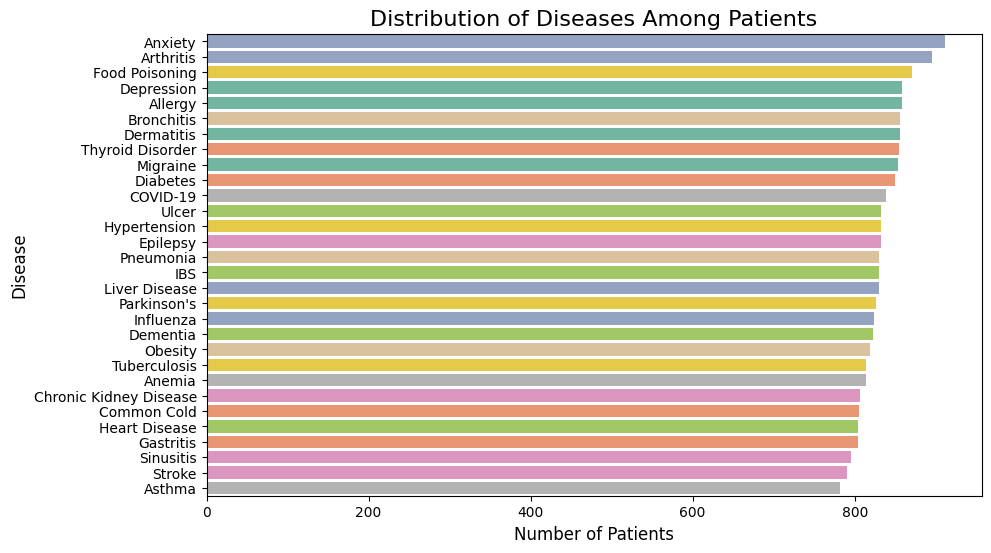

In [76]:
# 4. Visualization: Disease Distribution

# Bar Chart to show the number of patients per disease
plt.figure(figsize=(10, 6))

sns.countplot(data=df, y='Disease', order=df['Disease'].value_counts().index, palette='Set2', hue='Disease', legend=False)

plt.title('Distribution of Diseases Among Patients', fontsize=16)
plt.xlabel('Number of Patients', fontsize=12)
plt.ylabel('Disease', fontsize=12)

plt.show()

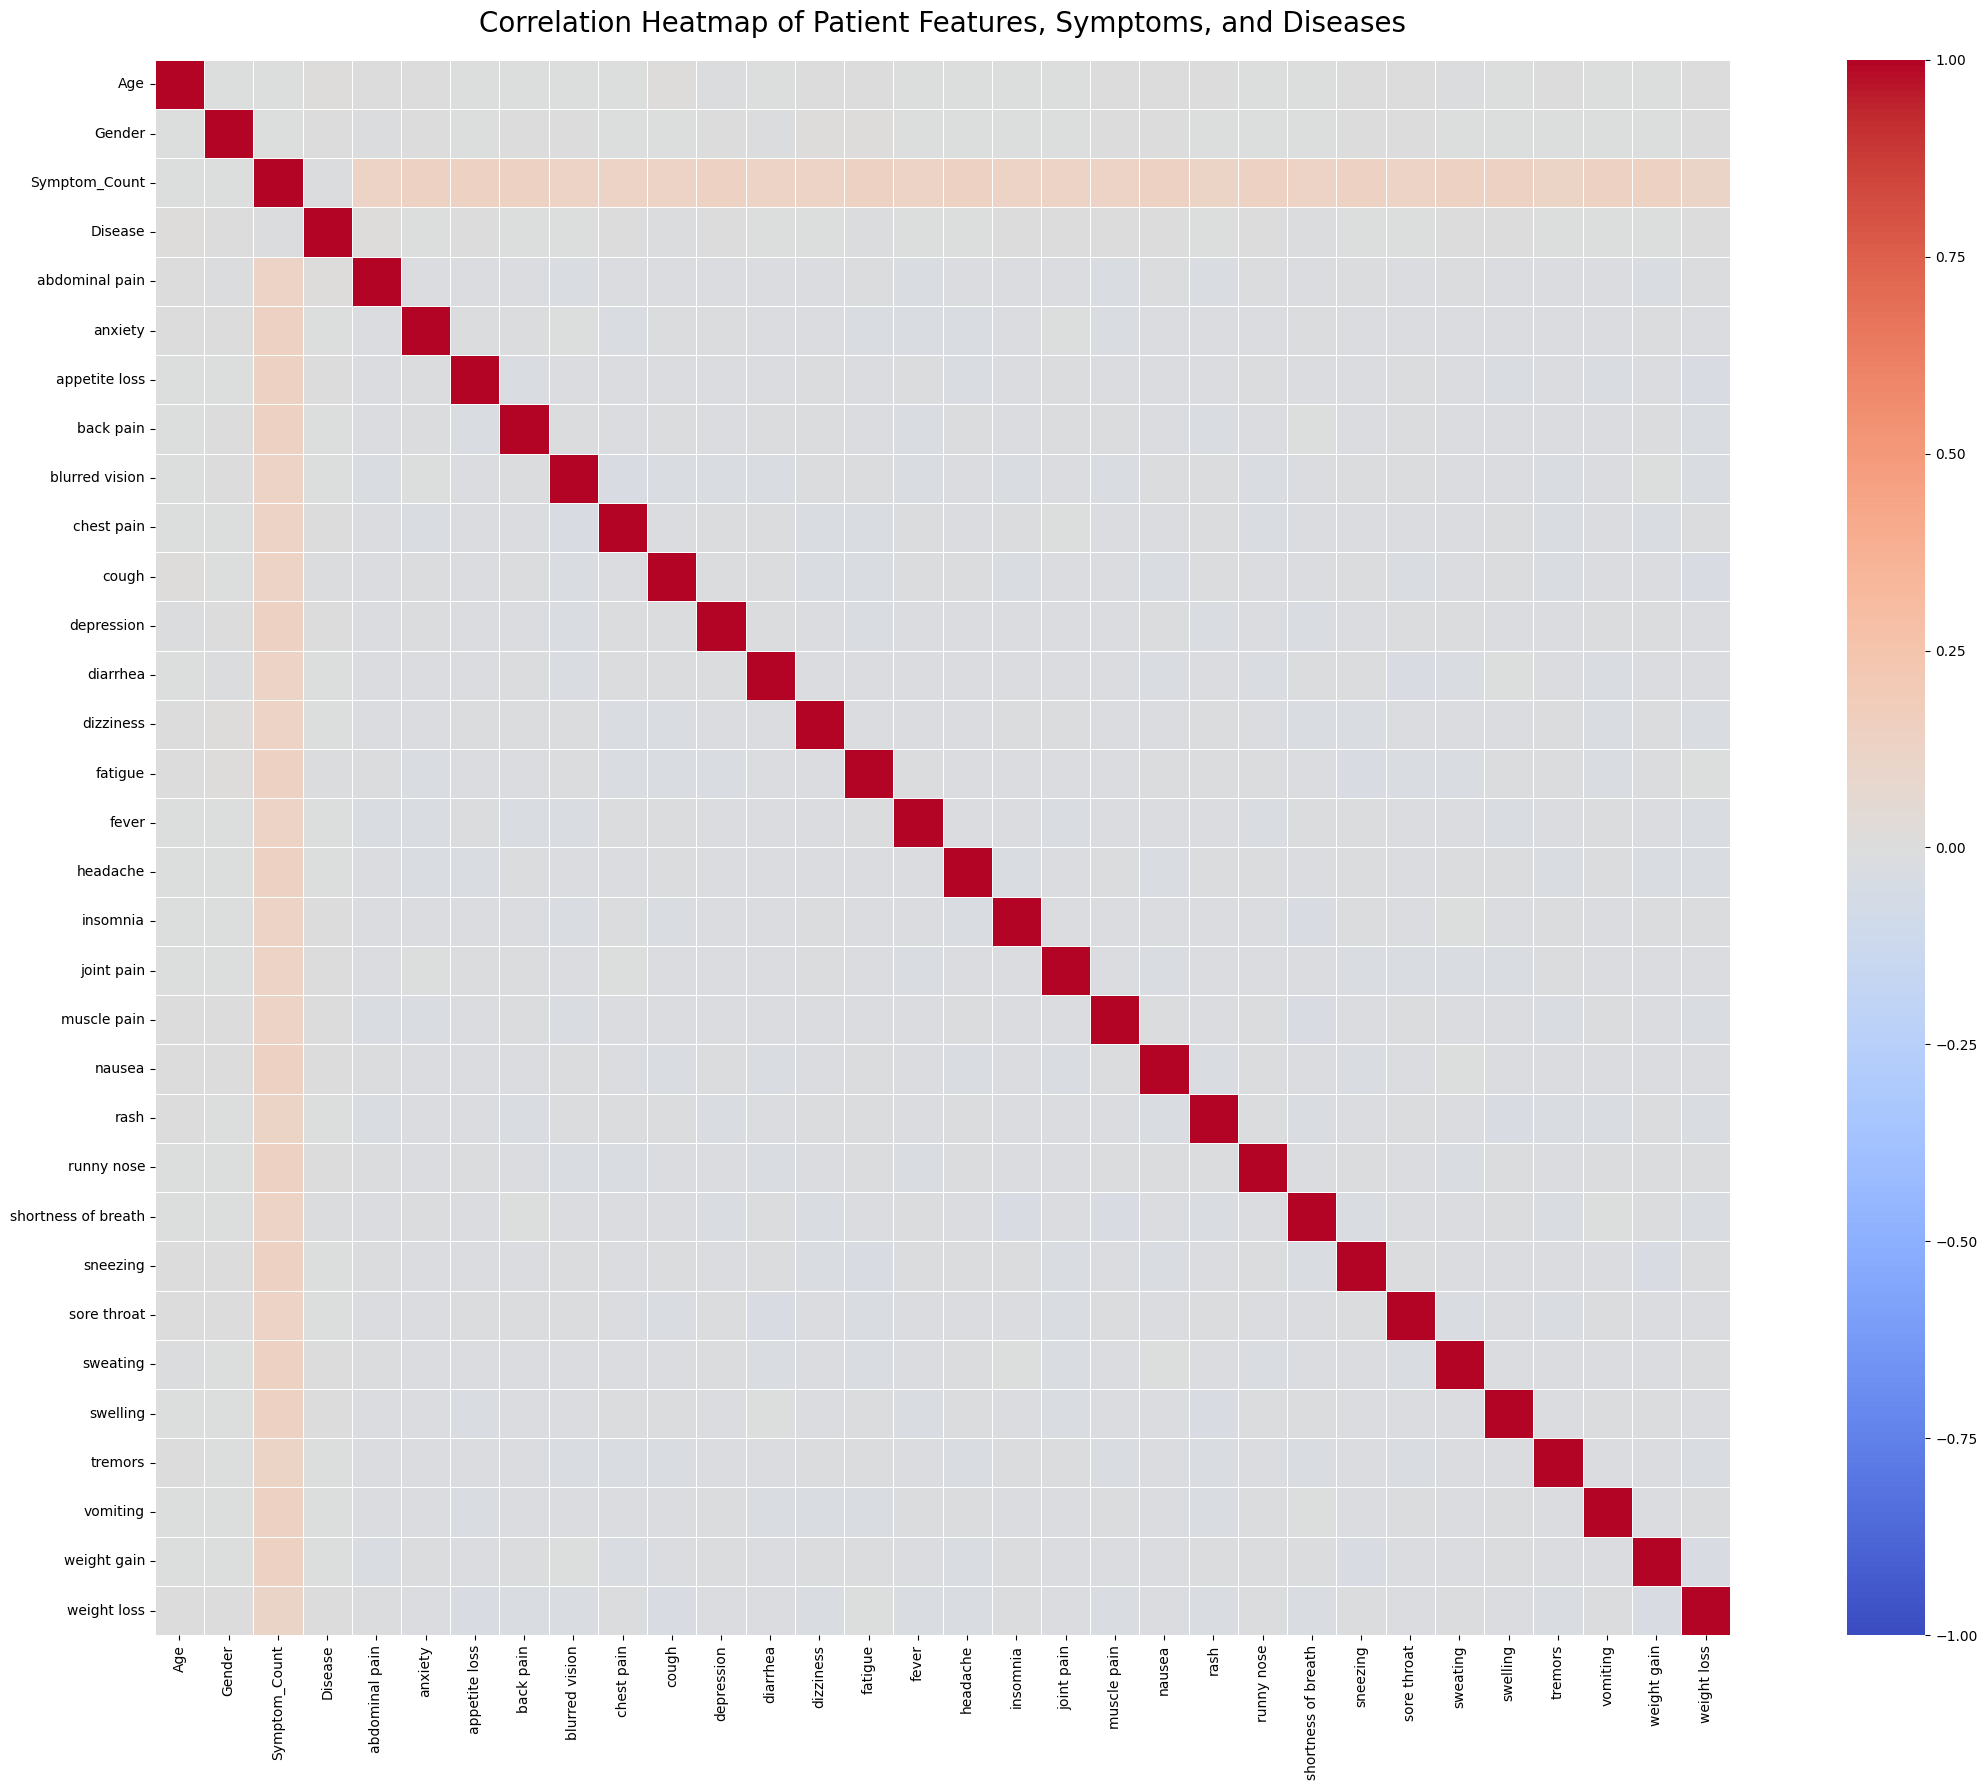

In [77]:
# 5. HeatMap (All Features and Symptoms)

corr_matrix = df_processed.corr()

# Set up the figure
plt.figure(figsize=(24, 18))

# Generate the heatmap
sns.heatmap(corr_matrix, 
            annot=False,          # Set to True if you want to see the numbers
            cmap='coolwarm',      # 'coolwarm' shows negative correlation in blue and positive in red
            linewidths=0.5,       # Adds borders to the cells for a cleaner look
            fmt='.2f',
            vmin=-1, vmax=1,      # Sets the scale from -1 to 1 (Pearson correlation)
            square=True)

# Add a title and adjust layout
plt.title('Correlation Heatmap of Patient Features, Symptoms, and Diseases', fontsize=20, pad=20)
plt.tight_layout()

plt.show()

In [78]:
# 6.0 . Visualization: Basic Features Correlation

# Map Gender to numbers in the original dataframe for visualization
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1, 'Other': 2})

print("Basic Features Correlation Matrix:")
display(df.corr(numeric_only=True))

Basic Features Correlation Matrix:


,Patient_ID,Age,Gender,Symptom_Count
Patient_ID,1.000000,-0.005099,-0.004463,-0.006466
Age,-0.005099,1.000000,-0.003434,-0.001266
Gender,-0.004463,-0.003434,1.000000,-0.001909
Symptom_Count,-0.006466,-0.001266,-0.001909,1.000000


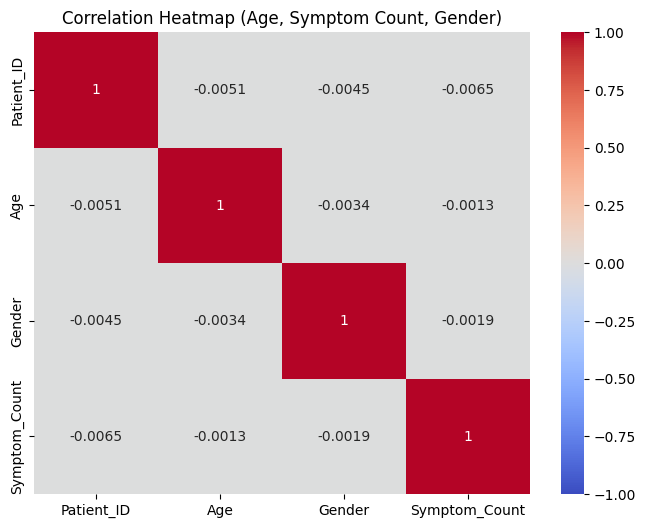

In [79]:
# 6.2. Visualization: Basic Features HeatMap

plt.figure(figsize=(8, 6))

sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, cmap='coolwarm')
plt.title('Correlation Heatmap (Age, Symptom Count, Gender)')

plt.show()

In [80]:
# 6.3 . Visualization: Filtered Strong Correlations

# Extract only strong correlations (> 0.3 or < -0.3)
f_corr = df.corr(numeric_only=True)[(df.corr(numeric_only=True) >= 0.3) | (df.corr(numeric_only=True) <= -0.3)]

print("Strong Correlations Filter:")
display(f_corr)

Strong Correlations Filter:


,Patient_ID,Age,Gender,Symptom_Count
Patient_ID,1.0,NaN,NaN,NaN
Age,NaN,1.0,NaN,NaN
Gender,NaN,NaN,1.0,NaN
Symptom_Count,NaN,NaN,NaN,1.0


Top 10 Features selected by Chi-Square:


,Feature,Chi2_Score
5,blurred vision,33.312587
13,headache,32.314262
21,sneezing,31.010683
1,abdominal pain,30.958084
15,joint pain,30.838209
9,diarrhea,29.412611
6,chest pain,28.801862
12,fever,27.142311
11,fatigue,27.121228
14,insomnia,26.593111


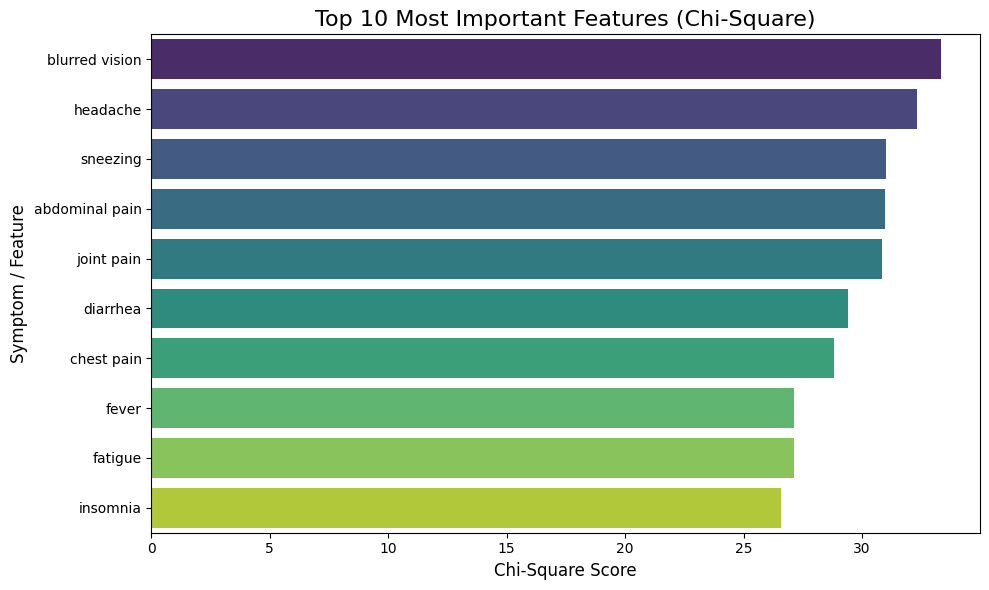

In [81]:
# 7. Feature Selection (Chi-square)

# Step 1: Define Features (X) and Target (y)
# Drop continuous columns (Age, Symptom_Count) bec Chi-Square is for categorical data
X = df_processed.drop(columns=['Disease', 'Age', 'Symptom_Count']) 
y = df_processed['Disease']

# Step 2: Apply Chi-Square test to find the top 10 symptoms related to diseases
chi2_selector = SelectKBest(score_func=chi2, k=10)
X_kbest = chi2_selector.fit_transform(X, y)

# Step 3: Organize the results in a dataframe
chi2_scores = chi2_selector.scores_
features = X.columns

chi2_results = pd.DataFrame({'Feature': features, 'Chi2_Score': chi2_scores})
chi2_results = chi2_results.sort_values(by='Chi2_Score', ascending=False)

# Display the table
print("Top 10 Features selected by Chi-Square:")
display(chi2_results.head(10))

# Step 4: Plot the results in a Bar Chart 
plt.figure(figsize=(10, 6))

# Used viridis palette and hue to match the required visual style without warnings
sns.barplot(x='Chi2_Score', y='Feature', data=chi2_results.head(10), palette='viridis', hue='Feature', legend=False)

# Set titles and labels
plt.title('Top 10 Most Important Features (Chi-Square)', fontsize=16)
plt.xlabel('Chi-Square Score', fontsize=12)
plt.ylabel('Symptom / Feature', fontsize=12)

plt.tight_layout()
plt.show()

In [82]:
### WEEK 2 ####


In [ ]:
# 8. Data Splitting based on Important Features

# we will use the top 10 features from Chi-Square + Age + Gender + Symptom_Count
important_symptoms = list(chi2_results['Feature'].head(10))
selected_columns = ['Age', 'Gender', 'Symptom_Count'] + important_symptoms

# Define X (Features) and y (Target)
X = df_processed[selected_columns]
y = df_processed['Disease']

# Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully split")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Data successfully split!
X_train shape: (20000, 13)
X_test shape: (5000, 13)


Decision Tree Evaluation:
Accuracy Score: 3.18%

Detailed Classification Report:
                        precision    recall  f1-score   support

               Allergy       0.03      0.04      0.03       161
                Anemia       0.03      0.02      0.03       171
               Anxiety       0.03      0.05      0.04       168
             Arthritis       0.04      0.06      0.05       174
                Asthma       0.02      0.03      0.02       151
            Bronchitis       0.05      0.08      0.07       170
              COVID-19       0.03      0.04      0.04       170
Chronic Kidney Disease       0.01      0.01      0.01       166
           Common Cold       0.05      0.05      0.05       165
              Dementia       0.00      0.00      0.00       166
            Depression       0.04      0.05      0.04       173
            Dermatitis       0.03      0.12      0.05       173
              Diabetes       0.01      0.01      0.01       174
              Epilepsy

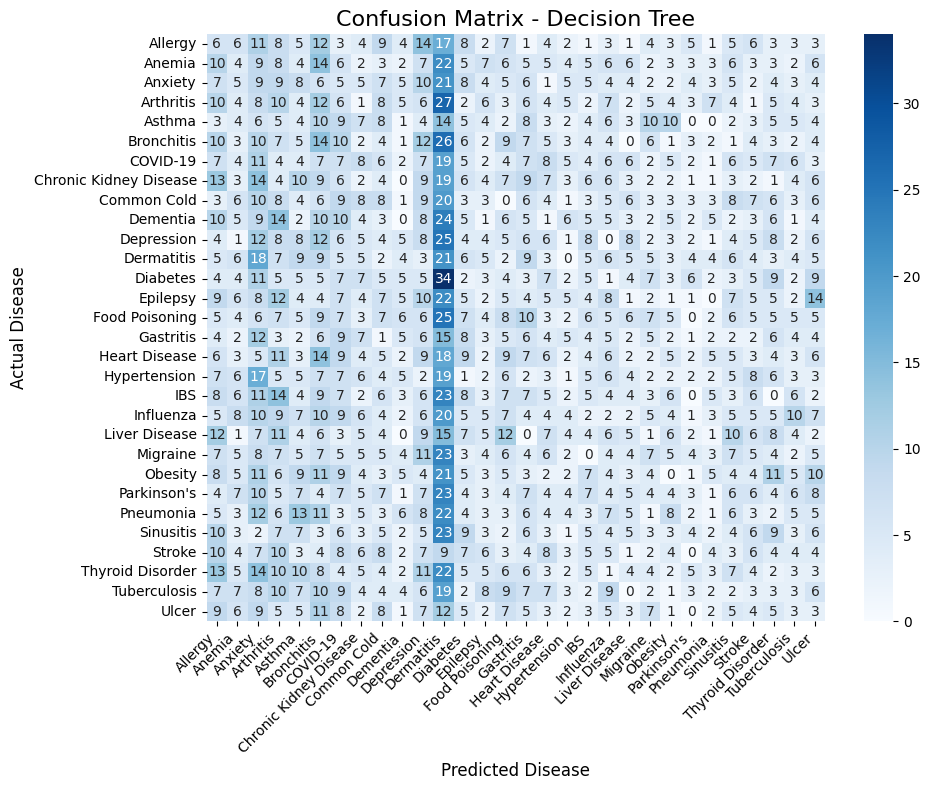

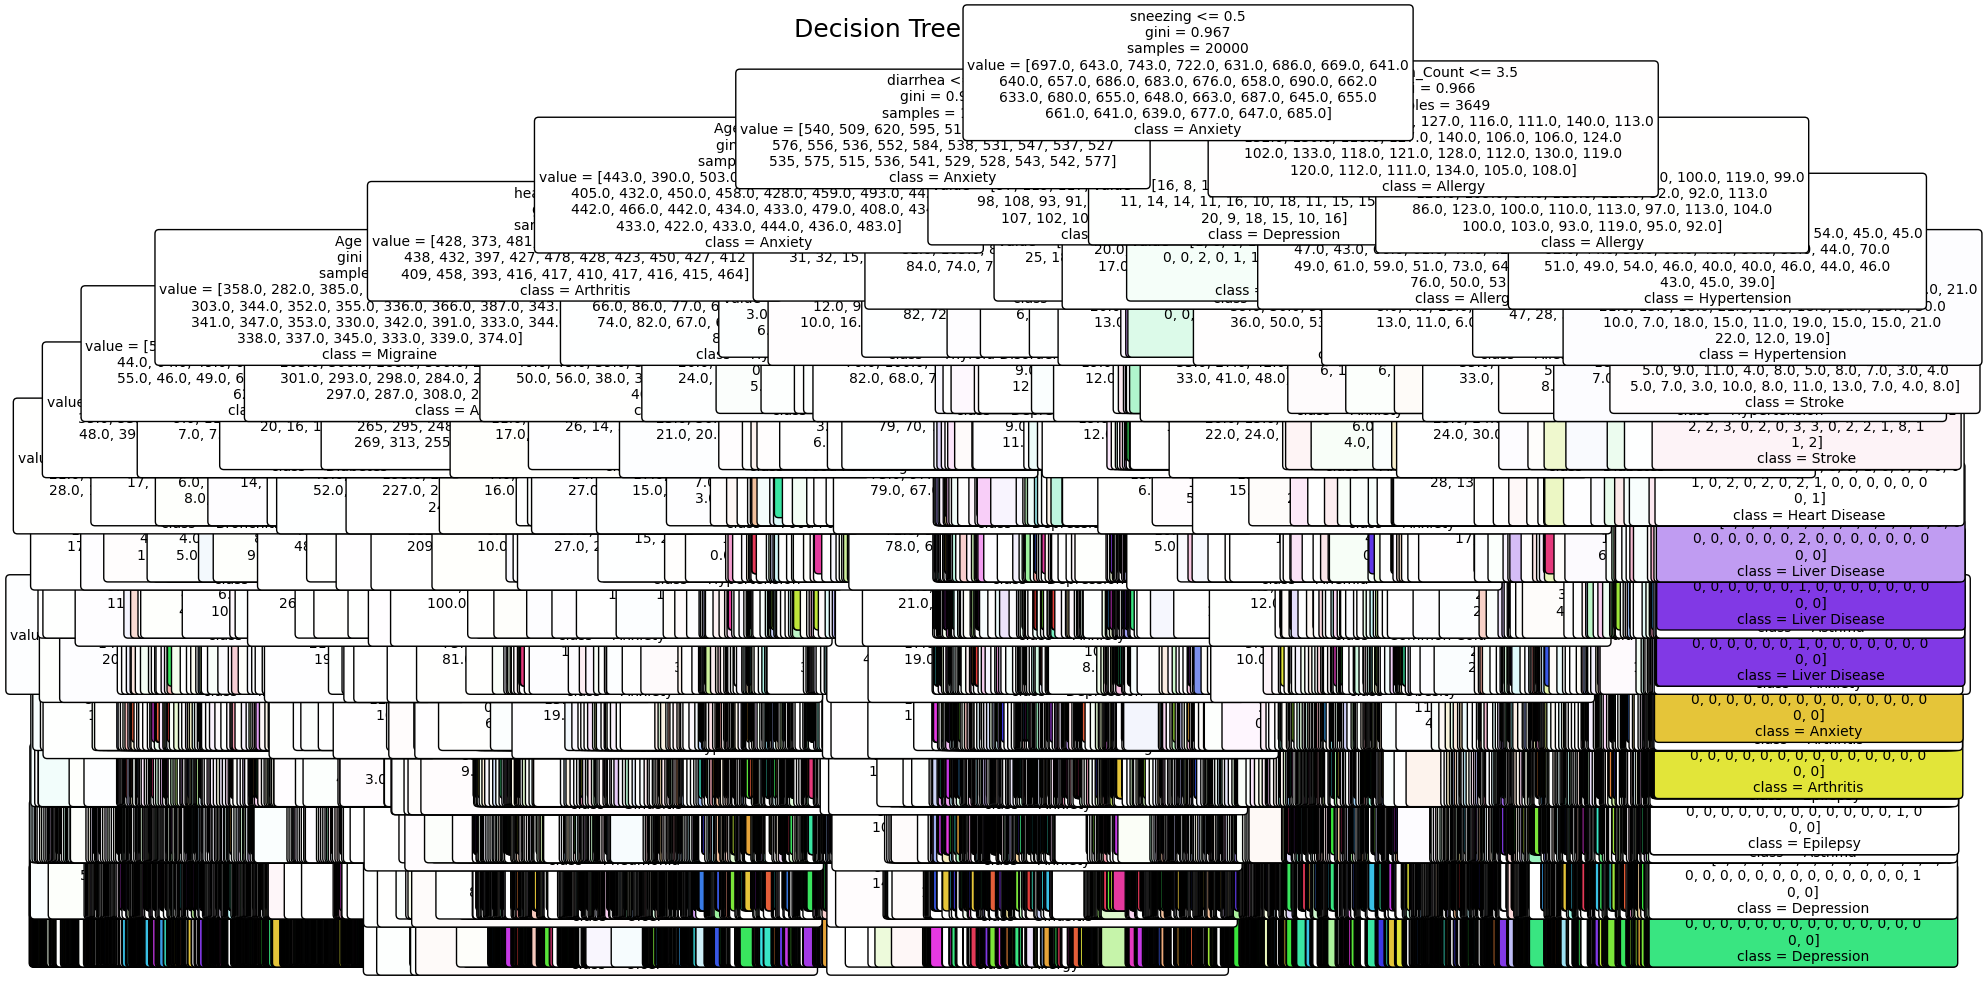

In [84]:
# 9. Applying Decision Tree & Evaluation Metrics

# Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=15, random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Basic Evaluation Metrics
print("Decision Tree Evaluation:")
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy Score: {dt_accuracy * 100:.2f}%\n")

# Advanced Evaluation Metrics
print("Detailed Classification Report:")
# Using target_names translates the encoded numbers back to disease names
print(classification_report(y_test, y_pred_dt, target_names=le_disease.classes_))

# Confusion Matrix Visualization
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_dt)

# Create heatmap for the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_disease.classes_, 
            yticklabels=le_disease.classes_)

plt.title('Confusion Matrix - Decision Tree', fontsize=16)
plt.xlabel('Predicted Disease', fontsize=12)
plt.ylabel('Actual Disease', fontsize=12)
plt.xticks(rotation=45, ha='right') 

plt.tight_layout()
plt.show()

# Visualize the Tree
plt.figure(figsize=(20, 10), dpi=100) 

# Draw the tree
plot_tree(dt_model, 
          feature_names=X_train.columns,            # Show symptom names on the branches
          class_names=le_disease.classes_,          # Show the actual disease names in the boxes
          filled=True,                              
          rounded=True,                             
          fontsize=10)

plt.title("Decision Tree Logic Visualization", fontsize=18)
plt.tight_layout()
plt.show()

In [85]:
# 10. Applying Naive Bayes Classifier

# Initialize the Naive Bayes model
nb_model = GaussianNB()

# Train the model 
nb_model.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test)

# Evaluation Metrics
print("Naive Bayes Evaluation:")
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy Score: {nb_accuracy * 100:.2f}%\n")

print("Detailed Classification Report:")
# Using target_names makes the report readable, and zero_division=0 hides the warning
print(classification_report(y_test, y_pred_nb, target_names=le_disease.classes_, zero_division=0))

Naive Bayes Evaluation:
Accuracy Score: 3.36%

Detailed Classification Report:
                        precision    recall  f1-score   support

               Allergy       0.03      0.07      0.05       161
                Anemia       0.04      0.06      0.04       171
               Anxiety       0.03      0.04      0.04       168
             Arthritis       0.03      0.04      0.04       174
                Asthma       0.03      0.01      0.01       151
            Bronchitis       0.05      0.07      0.06       170
              COVID-19       0.10      0.02      0.04       170
Chronic Kidney Disease       0.02      0.01      0.01       166
           Common Cold       0.05      0.05      0.05       165
              Dementia       0.02      0.02      0.02       166
            Depression       0.06      0.03      0.04       173
            Dermatitis       0.00      0.00      0.00       173
              Diabetes       0.01      0.01      0.01       174
              Epilepsy  

In [86]:
# 11. Neural Network Algorithm (Multi-Layer Perceptron)

# Scaling
# Neural Networks perform much better when all features are on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Initialize the Neural Network model
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

# 2. Train the model using the SCALED data
nn_model.fit(X_train_scaled, y_train)

# 3. Make predictions using the SCALED test data
y_pred_nn = nn_model.predict(X_test_scaled)

# 4. Evaluation Metrics
print("Neural Network Evaluation:")
nn_accuracy = accuracy_score(y_test, y_pred_nn)
print(f"Accuracy Score: {nn_accuracy * 100:.2f}%")

# Using target_names to make the report readable with disease names
print("\nClassification Report:\n", classification_report(y_test, y_pred_nn, target_names=le_disease.classes_))

Neural Network Evaluation:
Accuracy Score: 3.28%

Classification Report:
                         precision    recall  f1-score   support

               Allergy       0.02      0.02      0.02       161
                Anemia       0.02      0.02      0.02       171
               Anxiety       0.05      0.05      0.05       168
             Arthritis       0.05      0.06      0.05       174
                Asthma       0.04      0.04      0.04       151
            Bronchitis       0.02      0.05      0.03       170
              COVID-19       0.00      0.00      0.00       170
Chronic Kidney Disease       0.05      0.05      0.05       166
           Common Cold       0.02      0.01      0.01       165
              Dementia       0.04      0.02      0.03       166
            Depression       0.03      0.03      0.03       173
            Dermatitis       0.04      0.10      0.06       173
              Diabetes       0.01      0.01      0.01       174
              Epilepsy       

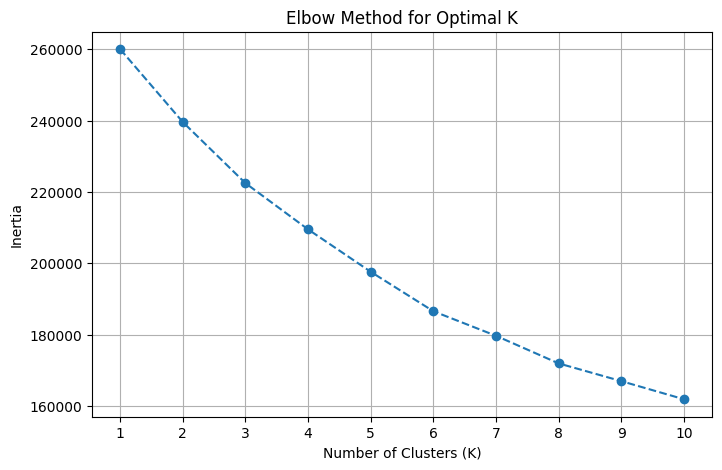

In [87]:
# 12.0 Elbow plot

# 1. Calculate Inertia for different values of K
inertia = []
K_range = range(1, 11) # try from 1 to 10 clusters

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_train_scaled)
    inertia.append(model.inertia_)

# 2. Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

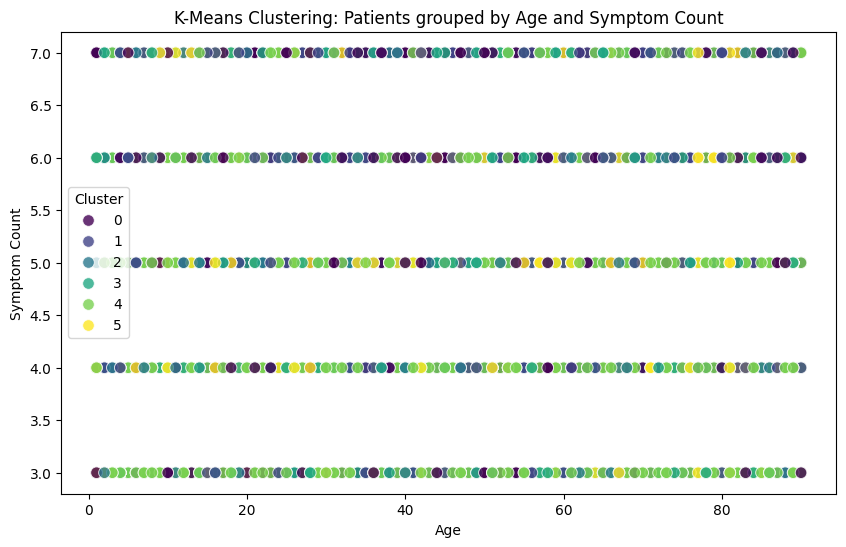

Silhouette Score (Quality of Clustering): 0.1254

Number of patients in each cluster:
Cluster
0    2995
1    3471
2    2031
3    2526
4    7182
5    1795
Name: count, dtype: int64


In [88]:
# 12.1 K-Means Clustering 

# Use scaled data for better clustering
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)

# Create dataframe for visualization
df_clusters = X_train.copy()
df_clusters['Cluster'] = clusters

# Visualization - Age vs Symptom Count
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clusters, 
                x='Age', 
                y='Symptom_Count', 
                hue='Cluster', 
                palette='viridis', 
                s=70, 
                alpha=0.8)
plt.title('K-Means Clustering: Patients grouped by Age and Symptom Count')
plt.xlabel('Age')
plt.ylabel('Symptom Count')
plt.legend(title='Cluster')
plt.show()

# Silhouette Score
sil_score = silhouette_score(X_train_scaled, clusters)
print(f"Silhouette Score (Quality of Clustering): {sil_score:.4f}")

# Show number of patients in each cluster
print("\nNumber of patients in each cluster:")
print(df_clusters['Cluster'].value_counts().sort_index())

Linear Regression Evaluation:
Mean Squared Error (MSE): 2.0180
R² Score: -0.0002


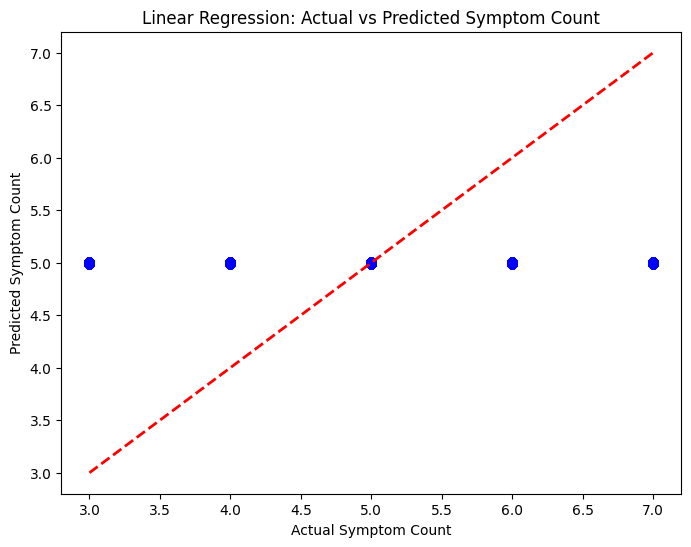


Model Coefficients:
Age coefficient: -0.0002
Gender coefficient: -0.0009


In [89]:
# 13. Linear Regression - Predicting Symptom_Count

# Use only Age and Gender to predict Symptom_Count
X_lr = df_processed[['Age', 'Gender']]
y_lr = df_processed['Symptom_Count']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

# Train the model
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

# Predictions
y_pred_lr = lr_model.predict(X_test_lr)

# Evaluation
print("Linear Regression Evaluation:")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_lr, y_pred_lr):.4f}")
print(f"R² Score: {r2_score(y_test_lr, y_pred_lr):.4f}")

# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test_lr, y_pred_lr, alpha=0.7, color='blue')
plt.plot([y_lr.min(), y_lr.max()], [y_lr.min(), y_lr.max()], 'r--', linewidth=2)
plt.title('Linear Regression: Actual vs Predicted Symptom Count')
plt.xlabel('Actual Symptom Count')
plt.ylabel('Predicted Symptom Count')
plt.show()

# Show coefficients
print("\nModel Coefficients:")
print(f"Age coefficient: {lr_model.coef_[0]:.4f}")
print(f"Gender coefficient: {lr_model.coef_[1]:.4f}")

In [90]:
# 14. Building the Interface using Gradio
import gradio as gr

# Define the prediction function that Gradio will use
def predict_disease(age, gender, symptom_count, *symptoms):
    # 1. Convert Gender from Text back to the Encoded Numbers (Male:0, Female:1, Other:2)
    gender_encoded = 0 if gender == 'Male' else 1
    
    # 2. Convert checkbox Boolean values (True/False) to Numbers (1/0)
    symptoms_encoded = [1 if symp else 0 for symp in symptoms]
    
    # 3. Combine all inputs into one single list (must match the X_train format)
    input_data = [age, gender_encoded, symptom_count] + symptoms_encoded
    
    # 4. Predict using our Naive Bayes model (nb_model)
    # We put input_data inside another list [] because the model expects a 2D array
    prediction_encoded = nb_model.predict([input_data])[0]
    
    # 5. Convert the predicted number back to the actual Disease Name
    disease_name = le_disease.inverse_transform([prediction_encoded])[0]
    
    return disease_name

### Create the Interface UI Components ###

# Base inputs
gui_inputs = [
    gr.Slider(minimum=1, maximum=100, step=1, label="Patient Age"),
    gr.Dropdown(choices=['Male', 'Female'], label="Patient Gender"),
    gr.Slider(minimum=1, maximum=10, step=1, label="Number of Symptoms (Symptom Count)")
]

# Dynamically add checkboxes for our Top 10 Important Symptoms
for symp in important_symptoms:
    gui_inputs.append(gr.Checkbox(label=symp.title()))

# Launch Gradio App
iface = gr.Interface(
    fn=predict_disease,
    inputs=gui_inputs,
    outputs=gr.Textbox(label="🩺 Predicted Disease", text_align="center"),
    title="Healthcare Disease Predictor 🏥",
    description="Enter the patient's details and check the symptoms they are experiencing to predict the potential disease.",
    theme="default"
)

# Set share=True to generate a public link for your presentation!
iface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7863

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


Using existing dataset file at: .gradio\flagged\dataset1.csv
